In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_price_prediction-train.csv")
df.head()

,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,stock,normal_stock,...,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller
0,2025-01-01 22:37:36.424,1008004,29302587134,185168612932,41900000,68000000,534463751667712,100630,NaN,NaN,...,41900000,0.0,0,0,4.975239,55.0,158,f,f,f
1,2025-01-02 01:45:48.634,1006671485,18087284916,166287259494,16900000,0,0,100013,NaN,NaN,...,14900000,5.0,1,1,4.936441,70.0,3955,t,f,f
2,2025-01-02 01:45:48.634,1006671485,18087284916,166287259497,11900000,13900000,474465164066816,100013,NaN,NaN,...,14900000,5.0,1,1,4.936441,70.0,3955,t,f,f
3,2025-01-02 01:45:48.634,1006671485,18087284916,166287259492,16900000,0,0,100013,NaN,NaN,...,14900000,5.0,1,1,4.936441,70.0,3955,t,f,f
4,2025-01-02 01:45:48.634,1006671485,18087284916,166287259490,16900000,0,0,100013,NaN,NaN,...,14900000,5.0,1,1,4.936441,70.0,3955,t,f,f


# EDA — Exploratory Data Analysis
Before building a model, we first need to understand the data.
EDA answers 4 main questions:
1. How big is the data?
2. What are the columns and their data types?
3. Are there any missing values?
4. Does the data make sense?

## 1. Data Size
Check the number of rows and columns.

In [3]:
# Check data dimensions
df.shape

(306226, 26)

**Insight**: The dataset contains 306,226 scraping events with 26 columns of information per row. This is a fairly large dataset, so training the model will take a few minutes.

## 2. Data Types and Non-Null Count
Check the column names, their data types, and the number of non-null values per column.

In [4]:
# Check data types for each column & the number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306226 entries, 0 to 306225
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   capturedAt                306226 non-null  object 
 1   shopId                    306226 non-null  int64  
 2   itemId                    306226 non-null  int64  
 3   modelId                   306226 non-null  int64  
 4   price                     306226 non-null  int64  
 5   priceBeforeDiscount       306226 non-null  int64  
 6   promotionId               306226 non-null  int64  
 7   cat_id                    306226 non-null  int64  
 8   stock                     3738 non-null    float64
 9   normal_stock              3738 non-null    float64
 10  raw_discount              306226 non-null  int64  
 11  show_discount             306226 non-null  int64  
 12  brand                     200562 non-null  object 
 13  is_free_shipping          306226 non-null  o

**Insight:** There are 6 columns with object (text) types, namely capturedAt, brand, is_free_shipping, is_pre_order, is_official_shop, is_verified, is_preferred_plus_seller. All of them must be converted to numbers because ML models only accept numerical values.

## 3. Missing Values
Check the number of missing values per column and determine how to handle them.

In [5]:
# Check the number of non-null values for each column
df.isnull().sum()

capturedAt                       0
shopId                           0
itemId                           0
modelId                          0
price                            0
priceBeforeDiscount              0
promotionId                      0
cat_id                           0
stock                       302488
normal_stock                302488
raw_discount                     0
show_discount                    0
brand                       105664
is_free_shipping                 0
is_pre_order                     0
item_price_min                   0
item_price_max                   0
review_rating                    0
total_rating_count               0
cmt_count                        0
shop_rating                      0
shop_response_rate            1199
shop_follower_count              0
is_official_shop                 0
is_verified                      0
is_preferred_plus_seller         0
dtype: int64

**Insight:** Found 4 columns with missing values:
- stock and normal_stock → 98.8% missing → dropped, no useful information
- brand → 34.5% missing → filled with 'unknown', unbranded products are still valid
- shop_response_rate → 0.4% missing → filled with median, assuming an average shop

## 4. Price Distribution (Target Variable)
Price is the column we want to predict. We need to understand
its distribution before determining how to train the model.

In [6]:
# Understand the characteristics of the target column to be predicted
pd.options.display.float_format = '{:,.0f}'.format
print(df['price'].describe())
pd.reset_option('display.float_format')

count         306,226
mean       52,341,462
std        91,371,957
min           100,000
25%         9,900,000
50%        20,500,000
75%        59,000,000
max     1,660,000,000
Name: price, dtype: float64


**Insight:** The minimum price is Rp 100,000, the maximum is Rp 1.66 billion, a very wide range. The mean (Rp 52 million) is much larger than the median (Rp 20.5 million), which is a sign of a right-skewed distribution. There is a handful of very expensive products pulling the average up. The standard deviation (Rp 91 million) is greater than the mean, indicating that prices vary greatly. The majority of products are actually under Rp 20.5 million.

## 5. Price Distribution Visualization
Comparison of the original price distribution vs. log price to understand
why we need a log transformation before training the model.

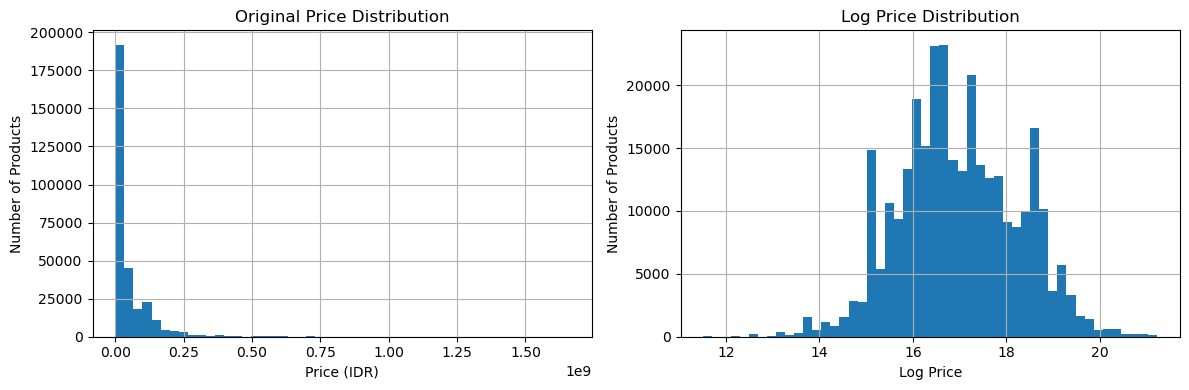

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left chart: original price distribution
df['price'].hist(bins=50, ax=axes[0])
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price (IDR)')
axes[0].set_ylabel('Number of Products')

# Right chart: log price distribution
np.log1p(df['price']).hist(bins=50, ax=axes[1])
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

**Insight:** The original price is highly skewed because the chart is clustered on the left with a long tail to the right. After applying log, the distribution is much more symmetrical. ML models work better with symmetrical distributions, so we will use log(price) as the target during training later.


## 6. Price Distribution per Category
Check if prices differ significantly across categories. This determines how important cat_id is as a model feature.

In [8]:
cat_stats = (
    df.groupby('cat_id')['price']
    .agg(['median', 'count'])
    .sort_values('count', ascending=False)
    .reset_index()
)
print(cat_stats)


    cat_id       median  count
0   100636   25000000.0  67450
1   100001   15900000.0  36645
2   100630   13900000.0  36235
3   100015   14900000.0  32995
4   100632  108000000.0  20818
5   100638   16500000.0  19274
6   100637   69900000.0  19186
7   100629    9300000.0  13430
8   100010  168000000.0   9879
9   100631   81000000.0   9420
10  100633   29000000.0   9381
11  100016   13900000.0   6038
12  100012   42300000.0   5943
13  100641   99900000.0   4125
14  100017    7900000.0   2808
15  100532   39000000.0   2751
16  100635   21500000.0   2106
17  100011    3500000.0   2053
18  100639   29800000.0   1887
19  100013   20500000.0   1274
20  100640   37500000.0   1001
21  100009   15900000.0    759
22  100533    9900000.0    520
23  100644  419900000.0    140
24  100643   46900000.0     71
25  100535   69900000.0     37


**Insight:** The median price across categories varies greatly, from Rp 3.5 million (cat_id 100011) to Rp 419.9 million (cat_id 100644). cat_id is a very strong feature for price prediction. Categories with little data (< 100 rows) will result in less accurate predictions.

## 7. Price Trends Over Time
Visualization of the daily median price to see if there are upward/downward trends or specific events affecting the price during the training period.


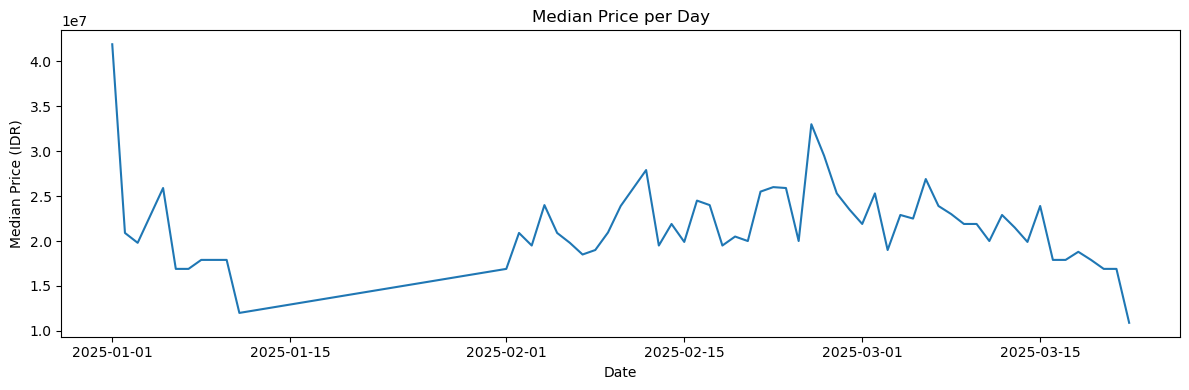

In [9]:
df['capturedAt'] = pd.to_datetime(df['capturedAt'])
df['date'] = df['capturedAt'].dt.date

harga_harian = df.groupby('date')['price'].median()

plt.figure(figsize=(12, 4))
harga_harian.plot()
plt.title('Median Price per Day')
plt.xlabel('Date')
plt.ylabel('Median Price (IDR)')
plt.tight_layout()
plt.show()

**Insight:** Prices are not entirely stable. There are quite visible daily fluctuations, especially in early January and late March. The spike in early January is likely an anomaly because there is very little data on that day. Generally, prices hover in the Rp 15–25 million range throughout February–March.

Implications for the model:
- These daily fluctuations are the reason why anchor calibration is important, because
  the model needs to know whether the prediction day is currently high or low.
- A time-based split must be used, because we must not use future data
  to predict the past.

In [10]:
# Save preprocessed df for next notebook
df.to_csv('data_raw.csv', index=False)
print('✓ Saved: data_raw.csv')

✓ Saved: data_raw.csv
